### Exercise 1: Annotated Line Graph for Temperature Records


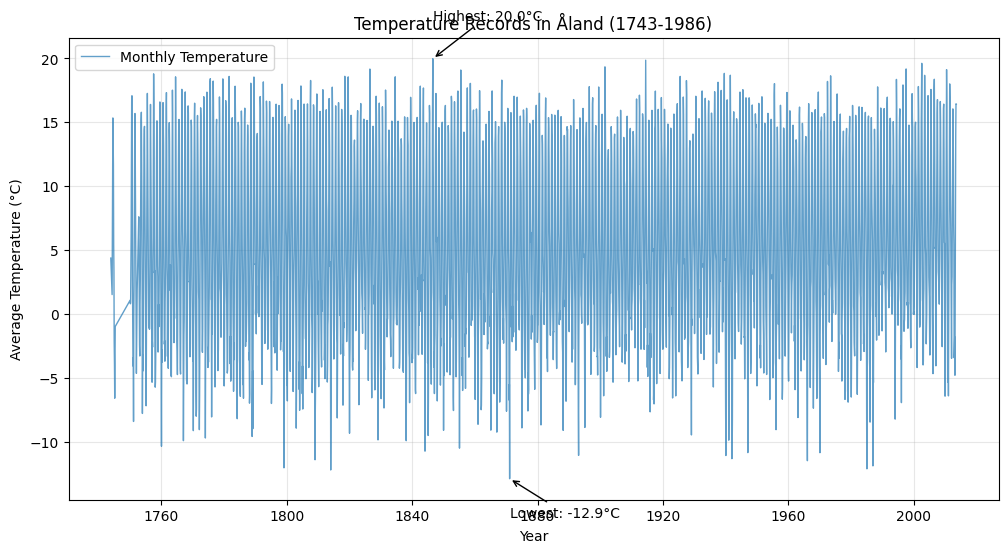

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('GlobalLandTemperaturesByCountry.csv')
aland_data = df[df['Country'] == 'Åland'].copy()
aland_data['dt'] = pd.to_datetime(aland_data['dt'])
aland_data = aland_data.dropna(subset=['AverageTemperature']).sort_values('dt')

# Extreme temperature events
max_temp = aland_data.loc[aland_data['AverageTemperature'].idxmax()]
min_temp = aland_data.loc[aland_data['AverageTemperature'].idxmin()]

# Annotated line graph
plt.figure(figsize=(12, 6))
plt.plot(aland_data['dt'], aland_data['AverageTemperature'], linewidth=1, alpha=0.7, label='Monthly Temperature')

# Annotate extremes
plt.annotate(f'Highest: {max_temp["AverageTemperature"]:.1f}°C', 
             xy=(max_temp['dt'], max_temp['AverageTemperature']),
             xytext=(max_temp['dt'], max_temp['AverageTemperature'] + 3),
             arrowprops=dict(arrowstyle='->'),
             fontsize=10)

plt.annotate(f'Lowest: {min_temp["AverageTemperature"]:.1f}°C', 
             xy=(min_temp['dt'], min_temp['AverageTemperature']),
             xytext=(min_temp['dt'], min_temp['AverageTemperature'] - 3),
             arrowprops=dict(arrowstyle='->'),
             fontsize=10)

plt.title('Temperature Records in Åland (1743-1986)')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Exercise 2: Hierarchical Filtering and Visualization


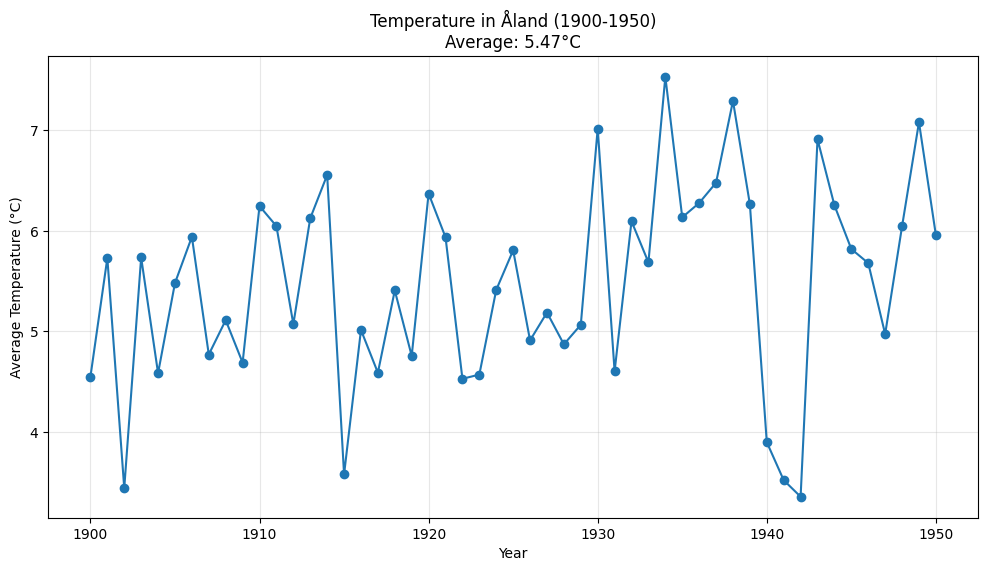

In [3]:
# Filteingr  for specific date range
start_year = 1900
end_year = 1950

filtered_data = aland_data[
    (aland_data['dt'].dt.year >= start_year) & 
    (aland_data['dt'].dt.year <= end_year)
].copy()

# Average temperature 
average_temp = filtered_data['AverageTemperature'].mean()

# Hierarchical structure and visualization
filtered_data['Year'] = filtered_data['dt'].dt.year
yearly_avg = filtered_data.groupby('Year')['AverageTemperature'].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.title(f'Temperature in Åland ({start_year}-{end_year})\nAverage: {average_temp:.2f}°C')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

### Exercise 3: Dynamic Subplot Configuration


C:\Users\PC\AppData\Local\Temp\ipykernel_6968\153392290.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(seasonal_data, labels=['Winter', 'Spring', 'Summer', 'Fall'])


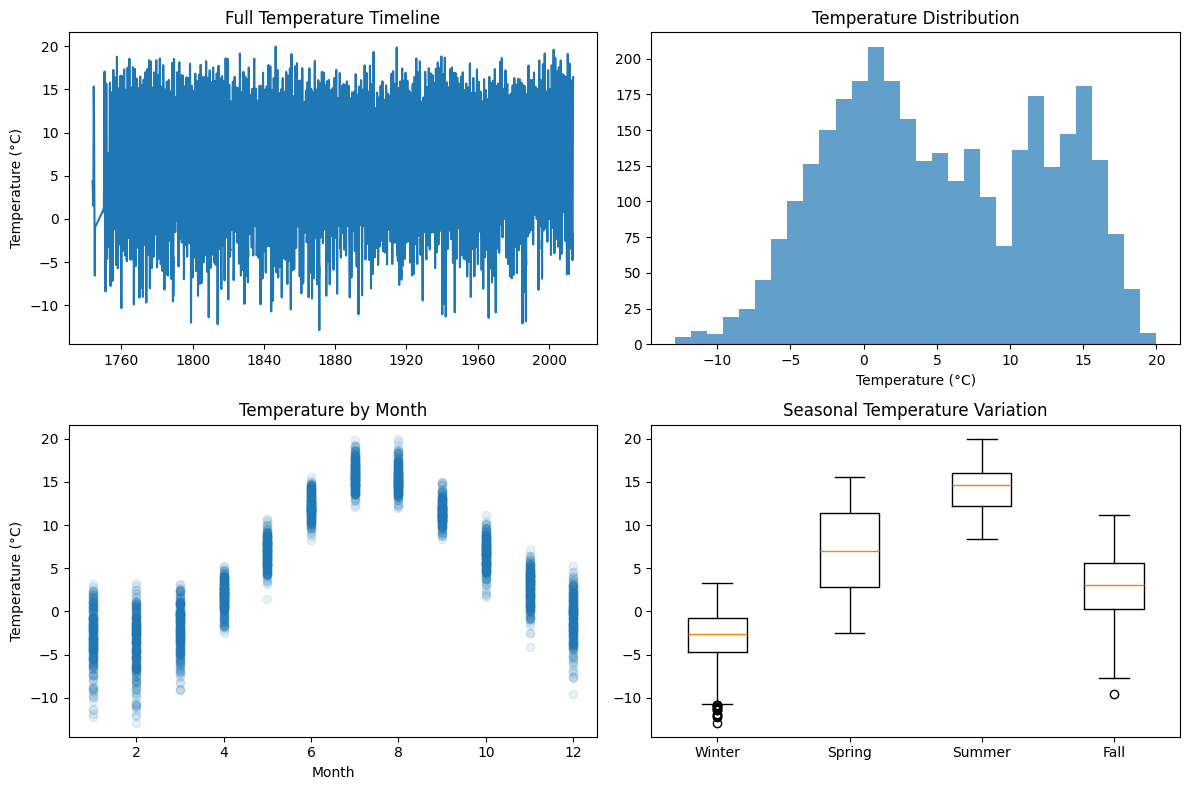

In [6]:
# Dynamic subplot based on user input
num_plots = 4 

# Grid layout
import math
rows = math.ceil(num_plots / 2)
cols = 2 if num_plots > 1 else 1

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))

# Flatten axes array to make indexing easier
if num_plots > 1:
    axes = axes.flatten()

plot_data = aland_data.copy()
plot_data['Year'] = plot_data['dt'].dt.year
plot_data['Month'] = plot_data['dt'].dt.month

#  Line plot - Full temperature timeline
if num_plots >= 1:
    ax = axes[0] if num_plots > 1 else axes
    ax.plot(plot_data['dt'], plot_data['AverageTemperature'])
    ax.set_title('Full Temperature Timeline')
    ax.set_ylabel('Temperature (°C)')

#  Histogram - Temperature distribution
if num_plots >= 2:
    ax = axes[1]
    ax.hist(plot_data['AverageTemperature'], bins=30, alpha=0.7)
    ax.set_title('Temperature Distribution')
    ax.set_xlabel('Temperature (°C)')

#  Scatter plot - Temperature by month
if num_plots >= 3:
    ax = axes[2]
    ax.scatter(plot_data['Month'], plot_data['AverageTemperature'], alpha=0.1)
    ax.set_title('Temperature by Month')
    ax.set_xlabel('Month')
    ax.set_ylabel('Temperature (°C)')

# Box plot - Seasonal variation
if num_plots >= 4:
    ax = axes[3]
    seasonal_data = [plot_data[plot_data['Month'].between(m, m+2)]['AverageTemperature'] 
                   for m in [1, 4, 7, 10]]
    ax.boxplot(seasonal_data, labels=['Winter', 'Spring', 'Summer', 'Fall'])
    ax.set_title('Seasonal Temperature Variation')

# Hide unused subplots if any
if num_plots > 1:
    for i in range(num_plots, len(axes)):
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### Exercise 4: Multi-Dimensional Analysis of Temperature Characteristics

In [3]:
# Data with multiple dimensions
aland_analysis = aland_data.copy()
aland_analysis['Year'] = aland_analysis['dt'].dt.year
aland_analysis['Decade'] = (aland_analysis['Year'] // 10) * 10
aland_analysis['Month'] = aland_analysis['dt'].dt.month
aland_analysis['Season'] = aland_analysis['Month'] % 12 // 3 + 1

# Temperature metrics by decade
decade_metrics = aland_analysis.groupby('Decade').agg({
    'AverageTemperature': ['mean', 'std', 'min', 'max'],
    'AverageTemperatureUncertainty': 'mean'
}).round(2)

decade_metrics.columns = ['Avg_Temp', 'Temp_Std', 'Min_Temp', 'Max_Temp', 'Uncertainty']
decade_metrics = decade_metrics.reset_index()

print("Temperature Metrics by Decade:")
print(decade_metrics.head(10))

Temperature Metrics by Decade:
   Decade  Avg_Temp  Temp_Std  Min_Temp  Max_Temp  Uncertainty
0    1740      3.26      6.82     -6.57     15.34         1.83
1    1750      4.98      7.23     -8.39     18.79         4.70
2    1760      5.05      7.34    -10.33     18.56         5.05
3    1770      5.40      7.78     -9.68     18.41         4.66
4    1780      4.72      7.99     -9.56     18.59         4.49
5    1790      5.65      7.07    -12.02     18.16         3.77
6    1800      4.65      7.80    -11.39     18.27         3.07
7    1810      4.89      7.39    -12.19     18.60         3.56
8    1820      5.43      7.24     -9.84     19.17         2.54
9    1830      4.89      7.12     -9.90     18.56         2.43


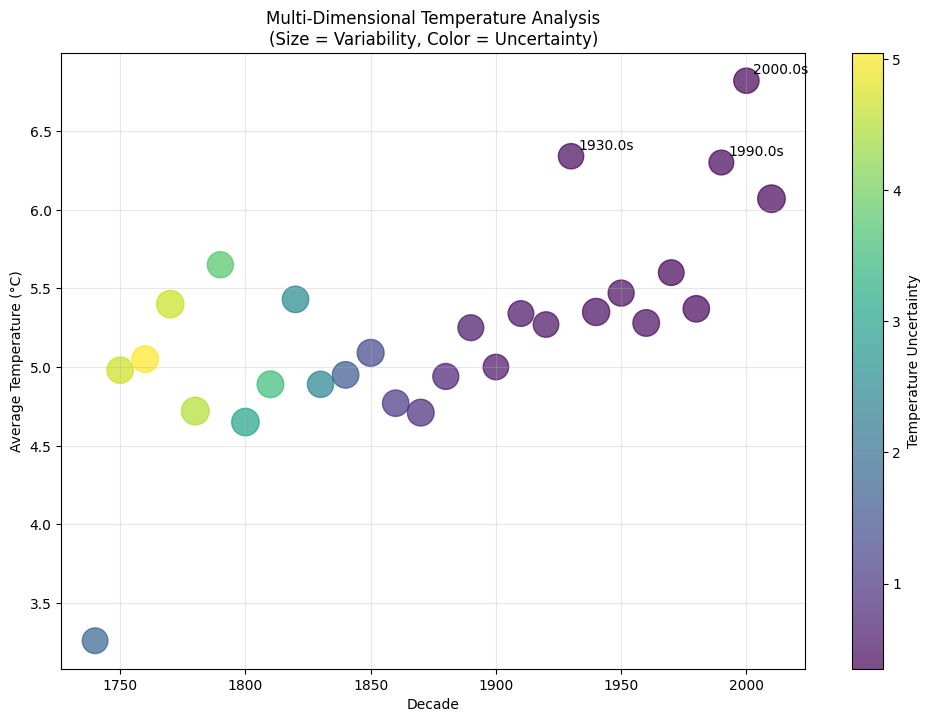

In [8]:
# Multi-dimensional scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(decade_metrics['Decade'], 
                     decade_metrics['Avg_Temp'],
                     s=decade_metrics['Temp_Std'] * 50,  # Size represents variability
                     c=decade_metrics['Uncertainty'],     # Color represents uncertainty
                     alpha=0.7,
                     cmap='viridis')

plt.colorbar(scatter, label='Temperature Uncertainty')
plt.xlabel('Decade')
plt.ylabel('Average Temperature (°C)')
plt.title('Multi-Dimensional Temperature Analysis\n(Size = Variability, Color = Uncertainty)')
plt.grid(True, alpha=0.3)

# Annotations for interesting decades
interesting_decades = decade_metrics.nlargest(3, 'Avg_Temp')
for _, row in interesting_decades.iterrows():
    plt.annotate(f"{row['Decade']}s", 
                (row['Decade'], row['Avg_Temp']),
                xytext=(5, 5), textcoords='offset points')

plt.show()

### Exercise 5: Predicting Temperature with Machine Learning


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

prediction_data = aland_data.copy()
prediction_data['Year'] = prediction_data['dt'].dt.year
prediction_data['Month'] = prediction_data['dt'].dt.month
prediction_data['DayOfYear'] = prediction_data['dt'].dt.dayofyear

# Time-based features
prediction_data['Year_sin'] = np.sin(2 * np.pi * prediction_data['Month']/12)
prediction_data['Year_cos'] = np.cos(2 * np.pi * prediction_data['Month']/12)

# lag features for time series prediction
prediction_data['Temp_lag1'] = prediction_data['AverageTemperature'].shift(1)
prediction_data['Temp_lag12'] = prediction_data['AverageTemperature'].shift(12)

# Remove rows with NaN values from lag features
prediction_data = prediction_data.dropna()

# Define features and target
features = ['Year', 'Month', 'DayOfYear', 'Year_sin', 'Year_cos', 'Temp_lag1', 'Temp_lag12']
X = prediction_data[features]
y = prediction_data['AverageTemperature']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Performance:
Mean Squared Error: 4.5034
R² Score: 0.9127


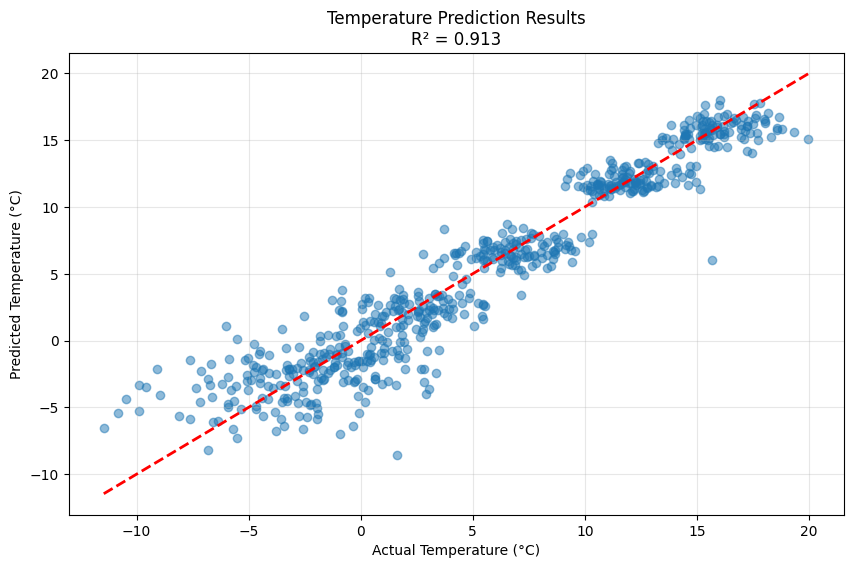


Feature Importance:
      feature  importance
6  Temp_lag12    0.834972
5   Temp_lag1    0.041604
1       Month    0.041270
2   DayOfYear    0.033251
0        Year    0.025704
4    Year_cos    0.014750
3    Year_sin    0.008449


In [7]:
# Predictions vs actual values visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title(f'Temperature Prediction Results\nR² = {r2:.3f}')
plt.grid(True, alpha=0.3)
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

### Exercise 6: Clustering Analysis to Identify Similar Temperature Patterns


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Prepare data; yearly temperature patterns
yearly_data = aland_data.copy()
yearly_data['Year'] = yearly_data['dt'].dt.year
yearly_data['Month'] = yearly_data['dt'].dt.month

# pivot table with monthly temperatures for each year
yearly_pivot = yearly_data.pivot_table(
    index='Year',
    columns='Month', 
    values='AverageTemperature',
    aggfunc='mean'
).dropna()

print(f"Years available for clustering: {len(yearly_pivot)}")
print("Monthly temperature data for clustering:")
print(yearly_pivot.head())

Years available for clustering: 260
Monthly temperature data for clustering:
Month     1      2      3      4      5       6       7       8       9   \
Year                                                                       
1753  -2.412 -3.273  0.710  2.778  6.226  11.102  15.159  15.786  12.106   
1754  -3.147 -4.444 -3.950  2.471  7.888  12.842  14.454  14.683  10.990   
1755  -5.508 -7.167 -4.352  2.818  7.581  13.364  17.261  13.704  10.562   
1756  -1.067  0.662 -1.182  0.474  4.810  13.363  16.399  13.464  11.083   
1757  -5.325 -2.160 -2.577  4.093  5.977  13.588  18.789  16.486  12.153   

Month     10     11     12  
Year                        
1753   8.756  2.248 -7.766  
1754   7.096  2.574 -0.040  
1755   7.176  2.284 -0.929  
1756   6.680 -0.801 -1.959  
1757   3.229  3.417 -2.704  


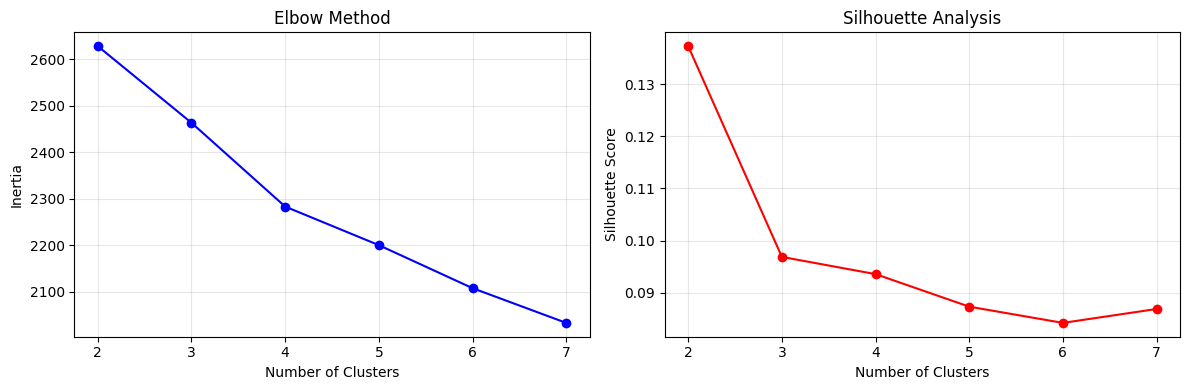

In [6]:
#  optimal number of clusters using elbow method
scaler = StandardScaler()
scaled_data = scaler.fit_transform(yearly_pivot)

inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, cluster_labels))

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertia, 'bo-')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

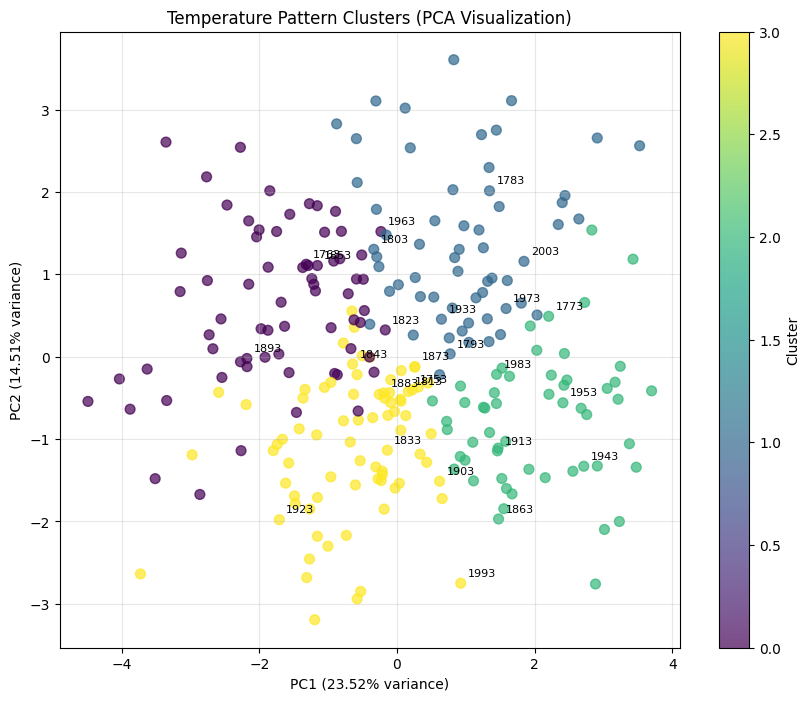

In [9]:
# Apply K-means clustering with optimal k
optimal_k = 4  
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

# Adding cluster labels to the data
yearly_pivot['Cluster'] = cluster_labels

# Reducing dimensions for visualization using PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

#  cluster visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], 
                     c=cluster_labels, cmap='viridis', s=50, alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Temperature Pattern Clusters (PCA Visualization)')
plt.grid(True, alpha=0.3)

# Addi,g year labels for some points
for i, year in enumerate(yearly_pivot.index[::10]):  
    plt.annotate(str(year), 
                (pca_components[i*10, 0], pca_components[i*10, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.show()

In [10]:
#  cluster characteristics
cluster_analysis = yearly_pivot.groupby('Cluster').mean()
cluster_sizes = yearly_pivot['Cluster'].value_counts().sort_index()

print("Cluster Sizes:")
print(cluster_sizes)
print("\nAverage Monthly Temperatures by Cluster:")
print(cluster_analysis.round(2))

Cluster Sizes:
Cluster
0    68
1    60
2    55
3    77
Name: count, dtype: int64

Average Monthly Temperatures by Cluster:
Month       1     2     3     4     5      6      7      8      9    10    11  \
Cluster                                                                         
0       -5.57 -6.83 -4.28  0.30  6.16  12.18  15.63  15.26  11.17  6.39  2.37   
1       -3.06 -3.20 -1.56  2.30  7.40  13.30  17.32  16.64  12.00  6.30  1.86   
2       -0.79 -1.06  0.25  3.30  7.85  12.34  15.85  15.76  12.19  7.72  4.04   
3       -2.08 -2.96 -2.20  1.57  6.34  11.31  14.92  14.43  11.12  6.60  2.42   

Month      12  
Cluster        
0       -1.31  
1       -1.33  
2        0.70  
3       -0.94  


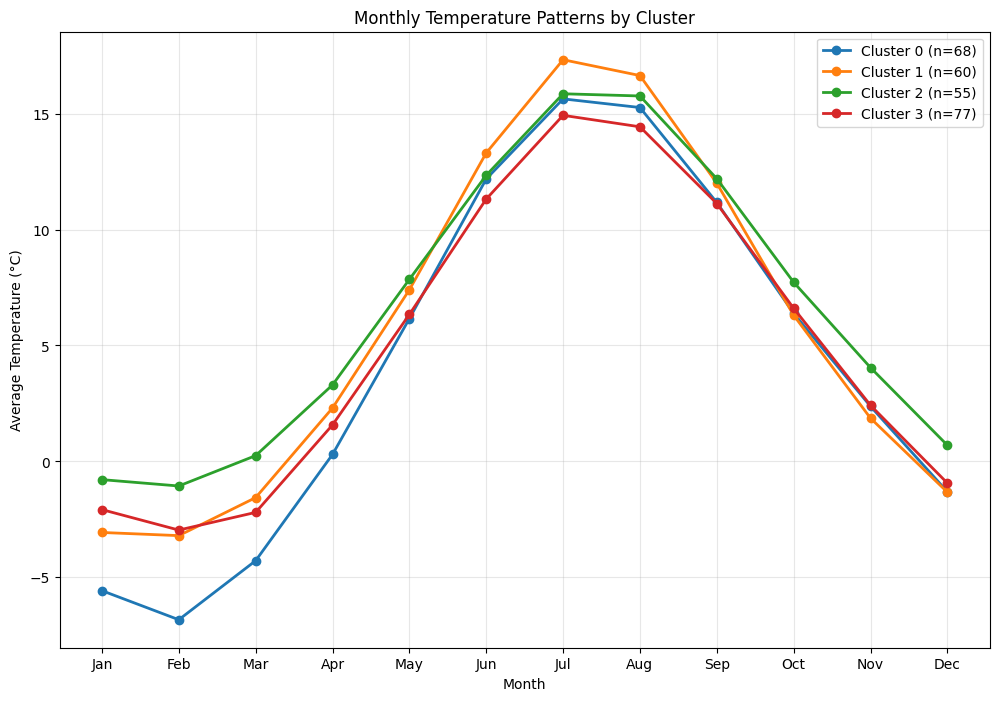

In [11]:
# Visualizing cluster patterns
plt.figure(figsize=(12, 8))
months = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for cluster_id in range(optimal_k):
    cluster_data = cluster_analysis.loc[cluster_id]
    plt.plot(months, cluster_data.values, 
             marker='o', linewidth=2, 
             label=f'Cluster {cluster_id} (n={cluster_sizes[cluster_id]})')

plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.title('Monthly Temperature Patterns by Cluster')
plt.xticks(months, month_names)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
print("CLUSTER INTERPRETATION:")
print("=" * 50)
for cluster_id in range(optimal_k):
    cluster_temps = cluster_analysis.loc[cluster_id]
    avg_annual_temp = cluster_temps.mean()
    temp_range = cluster_temps.max() - cluster_temps.min()
    
    print(f"\nCluster {cluster_id}:")
    print(f"  - Years: {cluster_sizes[cluster_id]}")
    print(f"  - Average Annual Temperature: {avg_annual_temp:.2f}°C")
    print(f"  - Annual Temperature Range: {temp_range:.2f}°C")
    print(f"  - Warmest Month: {month_names[cluster_temps.argmax()]} ({cluster_temps.max():.1f}°C)")
    print(f"  - Coldest Month: {month_names[cluster_temps.argmin()]} ({cluster_temps.min():.1f}°C)")

CLUSTER INTERPRETATION:

Cluster 0:
  - Years: 68
  - Average Annual Temperature: 4.29°C
  - Annual Temperature Range: 22.46°C
  - Warmest Month: Jul (15.6°C)
  - Coldest Month: Feb (-6.8°C)

Cluster 1:
  - Years: 60
  - Average Annual Temperature: 5.66°C
  - Annual Temperature Range: 20.52°C
  - Warmest Month: Jul (17.3°C)
  - Coldest Month: Feb (-3.2°C)

Cluster 2:
  - Years: 55
  - Average Annual Temperature: 6.51°C
  - Annual Temperature Range: 16.91°C
  - Warmest Month: Jul (15.9°C)
  - Coldest Month: Feb (-1.1°C)

Cluster 3:
  - Years: 77
  - Average Annual Temperature: 5.05°C
  - Annual Temperature Range: 17.88°C
  - Warmest Month: Jul (14.9°C)
  - Coldest Month: Feb (-3.0°C)
